# 9주차 LSTM 모델 실제 수익률 백테스팅 및 결과 분석

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F  # Softmax 확률 변환
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

In [2]:
class LSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(LSTMCell, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        
        self.W_f = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_i = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_s_tilde = nn.Linear(input_size + hidden_size, hidden_size)
        self.W_o = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x_t, hidden_state):
        h_prev, s_prev = hidden_state
        
        combined = torch.cat((x_t, h_prev), dim=1)
        
        f_t = torch.sigmoid(self.W_f(combined))
        i_t = torch.sigmoid(self.W_i(combined))
        s_tilde_t = torch.tanh(self.W_s_tilde(combined))
        s_t = f_t * s_prev + i_t * s_tilde_t
        o_t = torch.sigmoid(self.W_o(combined))
        h_t = o_t * torch.tanh(s_t)
        
        return h_t, s_t

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=25, output_size=2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        
        self.lstm_cell = LSTMCell(input_size, hidden_size)
        self.dropout = nn.Dropout(p=0.1)
        # 최종 출력은 2개 (하회할 점수, 상회할 점수)
        self.fc = nn.Linear(hidden_size, output_size) 

    def forward(self, x):
        batch_size = x.size(0)
        seq_length = x.size(1)
        
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        s_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        for t in range(seq_length):
            x_t = x[:, t, :] 
            h_t, s_t = self.lstm_cell(x_t, (h_t, s_t))
            
        out = self.dropout(h_t)
        out = self.fc(out)
        
        return out

In [3]:
#모델 객체 생성
model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
model.eval() # 평가 모드 전환 (Dropout 비활성화)

# 가짜 데이터 생성 (3개 종목, 30일치 시퀀스, 1개 피처)
dummy_data = torch.randn(3, 30, 1)

with torch.no_grad():
    # 모델에 넣고 결과 확인
    raw_output = model(dummy_data)
    print("모델의 원래 출력값:")
    print(raw_output)
    print("-" * 50)
    
    # Softmax를 씌워서 0~1 사이의 확률로 변환
    probabilities = F.softmax(raw_output, dim=1)
    print("Softmax 적용 후:")
    print(probabilities)
    print("-" * 50)
    
    # 우리가 진짜 원하는 것 "클래스 1(오를 확률)"만 쏙 빼오기
    prob_of_up = probabilities[:, 1]
    
    print("최종 추출: 각 종목이 시장 평균을 상회")
    for i, prob in enumerate(prob_of_up):
        print(f"주식 {i+1}이 오를 확률: {prob.item() * 100:.2f}%")

모델의 원래 출력값:
tensor([[0.1306, 0.0101],
        [0.1418, 0.0391],
        [0.1459, 0.0385]])
--------------------------------------------------
Softmax 적용 후:
tensor([[0.5301, 0.4699],
        [0.5256, 0.4744],
        [0.5268, 0.4732]])
--------------------------------------------------
최종 추출: 각 종목이 시장 평균을 상회
주식 1이 오를 확률: 46.99%
주식 2이 오를 확률: 47.44%
주식 3이 오를 확률: 47.32%


In [4]:
from torch.utils.data import TensorDataset, DataLoader

# 원본 데이터 불러오기
file_path = './processed_sequences/train_data_seq_30d.csv' 
df = pd.read_csv(file_path)

seq_length = 30
feature_cols = [f't-{seq_length - k}' for k in range(seq_length)]

# 첫 번째 Split(구간) 데이터만 분리해서 테스트
target_split = 1
split_df = df[df['split_id'] == target_split]

train_df = split_df[split_df['dataset_type'] == 'Train']
test_df = split_df[split_df['dataset_type'] == 'Test']

print(f"[Split {target_split}] 데이터 분리 완료")
print(f" - Train 데이터 개수: {len(train_df)}개")
print(f" - Test 데이터 개수: {len(test_df)}개")

# 3. PyTorch 텐서로 변환 (unsqueeze(-1)로 feature 차원 추가)
X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_train_tensor = torch.tensor(train_df['target'].values, dtype=torch.long)

X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
y_test_tensor = torch.tensor(test_df['target'].values, dtype=torch.long)

# DataLoader 생성
# Train은 학습을 위해 섞어도(shuffle=True) 되지만, 
# Test는 원본 데이터프레임(test_df)과 순서를 100% 일치시켜야 하므로 무조건 shuffle=False 입니다!
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

[Split 1] 데이터 분리 완료
 - Train 데이터 개수: 17040개
 - Test 데이터 개수: 6080개


In [5]:
import torch.optim as optim
import matplotlib.pyplot as plt

# 학습을 위한 준비
num_epochs = 40 # 빠른 확인을 위해 10번만 돌려qha
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters(), lr=0.001)

train_losses = []

print(f"[Split {target_split}] 모델 학습 시작...")

# 2. 모델 학습 (Train)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_loss:.4f}")

print("학습 끝")

# --- (여기서부터가 핵심!) ---
# 3. 모델 평가 및 확률 예측 (Test)
model.eval()
all_probs = [] # 모든 주식의 오를 확률을 담을 바구니

print("\n Test 데이터에 대한 확률 예측 시작...")
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        outputs = model(batch_X)
        
        # Softmax로 확률 변환 후, 클래스 1(오를 확률)만 추출
        probs = F.softmax(outputs, dim=1)
        prob_of_1 = probs[:, 1].cpu().numpy() 
        all_probs.extend(prob_of_1)

# 4. 원본 데이터프레임에 확률 매핑
test_df = test_df.copy() # Warning 방지
test_df['predict_prob'] = all_probs # 예측 확률 열 추가!

# 5. 날짜별 포트폴리오 구성 (상위 5개 매수, 하위 5개 공매도)
portfolio_list = []

for date, daily_data in test_df.groupby('target_date'):
    
    # 주식이 10개가 안 되는 날은 포트폴리오를 구성할 수 없으니 패스
    if len(daily_data) < 10:
        continue
        
    # 오를 확률('predict_prob')을 기준으로 1등부터 꼴등까지 줄 세우기
    sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
    
    # 상위 5개 매수 (Long)
    long_stocks = sorted_data.head(5).copy()
    long_stocks['position'] = 'Long'
    
    # 하위 5개 공매도 (Short)
    short_stocks = sorted_data.tail(5).copy()
    short_stocks['position'] = 'Short'
    
    portfolio_list.append(long_stocks)
    portfolio_list.append(short_stocks)

# 6. 최종 포트폴리오 결과 합치기
final_portfolio = pd.concat(portfolio_list)

print("포트폴리오 구성 완료!\n")
print("-" * 50)
print("[결과 확인] 첫 번째 날짜의 포트폴리오:")
sample_date = final_portfolio['target_date'].unique()[0]
result_display = final_portfolio[final_portfolio['target_date'] == sample_date][['target_date', 'ticker', 'predict_prob', 'position']]
print(result_display)
print("-" * 50)

[Split 1] 모델 학습 시작...
Epoch [1/40] Train Loss: 0.6673
Epoch [2/40] Train Loss: 0.6661
Epoch [3/40] Train Loss: 0.6663
Epoch [4/40] Train Loss: 0.6650
Epoch [5/40] Train Loss: 0.6649
Epoch [6/40] Train Loss: 0.6644
Epoch [7/40] Train Loss: 0.6638
Epoch [8/40] Train Loss: 0.6629
Epoch [9/40] Train Loss: 0.6608
Epoch [10/40] Train Loss: 0.6587
Epoch [11/40] Train Loss: 0.6490
Epoch [12/40] Train Loss: 0.6374
Epoch [13/40] Train Loss: 0.6325
Epoch [14/40] Train Loss: 0.6304
Epoch [15/40] Train Loss: 0.6292
Epoch [16/40] Train Loss: 0.6276
Epoch [17/40] Train Loss: 0.6266
Epoch [18/40] Train Loss: 0.6251
Epoch [19/40] Train Loss: 0.6234
Epoch [20/40] Train Loss: 0.6212
Epoch [21/40] Train Loss: 0.6195
Epoch [22/40] Train Loss: 0.6169
Epoch [23/40] Train Loss: 0.6147
Epoch [24/40] Train Loss: 0.6098
Epoch [25/40] Train Loss: 0.6082
Epoch [26/40] Train Loss: 0.6044
Epoch [27/40] Train Loss: 0.6018
Epoch [28/40] Train Loss: 0.5995
Epoch [29/40] Train Loss: 0.5966
Epoch [30/40] Train Loss: 0.59

In [6]:
# 테스트 데이터에 있는 첫 번째 날짜 가져오기
sample_date_all = test_df['target_date'].unique()[0]

# 해당 날짜의 전체 주식 데이터만 필터링
daily_all_stocks = test_df[test_df['target_date'] == sample_date_all].copy()

# 1이 될 확률(predict_prob)을 기준으로 내림차순(1등부터 꼴등까지) 정렬
daily_all_stocks_sorted = daily_all_stocks.sort_values(by='predict_prob', ascending=False)

# 보기 편하게 인덱스 초기화
daily_all_stocks_sorted = daily_all_stocks_sorted.reset_index(drop=True)

print(f"\n[{sample_date_all}] 전체 종목 예측 확률 랭킹 (1등 ~ 꼴등)")
print(" - predict_prob: 모델이 예측한 '시장 수익률 상회' 확률")
print(" - target: 실제 정답 (1=상회, 0=하회)\n")

# 필요한 주요 컬럼만 뽑아서 출력 (Jupyter 환경이므로 표 형태로 예쁘게 나옵니다)
display(daily_all_stocks_sorted[['target_date', 'ticker', 'predict_prob', 'target']])


[2022-07-09] 전체 종목 예측 확률 랭킹 (1등 ~ 꼴등)
 - predict_prob: 모델이 예측한 '시장 수익률 상회' 확률
 - target: 실제 정답 (1=상회, 0=하회)



,target_date,ticker,predict_prob,target
0,2022-07-09,XOM,0.981579,1
1,2022-07-09,GOOGL,0.981440,1
2,2022-07-09,CVX,0.981401,1
3,2022-07-09,AAPL,0.977635,1
4,2022-07-09,AMZN,0.977515,1
5,2022-07-09,MSFT,0.974978,1
6,2022-07-09,PLTR,0.971553,1
7,2022-07-09,CAT,0.970522,1
8,2022-07-09,NVDA,0.969271,1
9,2022-07-09,AMD,0.963465,1


In [7]:
# 만들어진 전체 포트폴리오 데이터프레임의 크기 확인
print(f"전체 포트폴리오 데이터 개수: {len(final_portfolio)}행")

# 보기 편하게 인덱스를 초기화
final_portfolio = final_portfolio.reset_index(drop=True)

# 첫 번째 날짜(하루치)의 포트폴리오(Long 5개, Short 5개)만 뽑아서 깔끔하게 출력
sample_date = final_portfolio['target_date'].unique()[0]
sample_daily_pf = final_portfolio[final_portfolio['target_date'] == sample_date]

print(f"\n[{sample_date}] 하루 동안의 포트폴리오 세팅 (상위 5개 Long / 하위 5개 Short)")
# 원하는 주요 컬럼만 선택해서 화면에 출력 (display는 주피터 환경에서 표를 예쁘게 그려줍니다)
display(sample_daily_pf[['target_date', 'ticker', 'predict_prob', 'position']])

전체 포트폴리오 데이터 개수: 1520행

[2022-07-09] 하루 동안의 포트폴리오 세팅 (상위 5개 Long / 하위 5개 Short)


,target_date,ticker,predict_prob,position
0,2022-07-09,XOM,0.981579,Long
1,2022-07-09,GOOGL,0.981440,Long
2,2022-07-09,CVX,0.981401,Long
3,2022-07-09,AAPL,0.977635,Long
4,2022-07-09,AMZN,0.977515,Long
5,2022-07-09,USDC-USD,0.516687,Short
6,2022-07-09,BNB-USD,0.492700,Short
7,2022-07-09,XRP-USD,0.487145,Short
8,2022-07-09,ADA-USD,0.481958,Short
9,2022-07-09,BTC-USD,0.476437,Short


In [8]:
# Long(매수)과 Short(공매도) 포트폴리오 나누기
long_pf = final_portfolio[final_portfolio['position'] == 'Long']
short_pf = final_portfolio[final_portfolio['position'] == 'Short']

# 2. 적중률 계산
# Long 적중률: 우리가 오를 거라고 해서 샀는데, 실제로 올랐는지(target == 1) 확인
long_hit_rate = (long_pf['target'] == 1).mean() * 100

# Short 적중률: 우리가 내릴 거라고 해서 팔았는데, 실제로 내렸는지(target == 0) 확인
short_hit_rate = (short_pf['target'] == 0).mean() * 100

# 3. 결과 출력
print(f"[Split {target_split}] 포트폴리오 적중률 (Hit Rate) 평가 결과")
print("-" * 50)
print(f"Long (상위 5개 매수) 적중률   : {long_hit_rate:.2f}%")
print(f"Short (하위 5개 공매도) 적중률 : {short_hit_rate:.2f}%")
print("-" * 50)
print(f"전체 포트폴리오 평균 적중률   : {(long_hit_rate + short_hit_rate) / 2:.2f}%")

[Split 1] 포트폴리오 적중률 (Hit Rate) 평가 결과
--------------------------------------------------
Long (상위 5개 매수) 적중률   : 66.45%
Short (하위 5개 공매도) 적중률 : 51.05%
--------------------------------------------------
전체 포트폴리오 평균 적중률   : 58.75%


In [9]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# 초기 세팅
unique_splits = sorted(df['split_id'].unique())

all_split_results = []
all_portfolios = []  # 시각화 셀로 넘겨줄 거대한 포트폴리오 바구니!

num_epochs = 40
print("백테스트(학습 및 종목 선정)\n")

# 전체 Split 반복 학습
for split_id in unique_splits:
    print(f"--- [Split {split_id}] 학습 및 평가 ---")
    
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0:
        continue 
        
    X_train_tensor = torch.tensor(train_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_train_tensor = torch.tensor(train_df['target'].values, dtype=torch.long)
    X_test_tensor = torch.tensor(test_df[feature_cols].values, dtype=torch.float32).unsqueeze(-1)
    y_test_tensor = torch.tensor(test_df['target'].values, dtype=torch.long)

    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)
    
    model = LSTMModel(input_size=1, hidden_size=25, output_size=2)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    
    model.train()
    for epoch in range(num_epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            probs = F.softmax(model(batch_X), dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())

    # 포트폴리오 구성 (상위 5 Long, 하위 5 Short)
    test_df = test_df.copy()
    test_df['predict_prob'] = all_probs
    
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10:
            continue
            
        sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
        
        long_stocks = sorted_data.head(5).copy()
        long_stocks['position'] = 'Long'
        
        short_stocks = sorted_data.tail(5).copy()
        short_stocks['position'] = 'Short'
        
        portfolio_list.append(long_stocks)
        portfolio_list.append(short_stocks)
        
    if not portfolio_list:
        continue
        
    split_portfolio = pd.concat(portfolio_list)
    all_portfolios.append(split_portfolio) # 바구니에 담기!

    # 단순 적중률 계산
    long_pf = split_portfolio[split_portfolio['position'] == 'Long']
    short_pf = split_portfolio[split_portfolio['position'] == 'Short']
    long_hit = (long_pf['target'] == 1).mean() * 100
    short_hit = (short_pf['target'] == 0).mean() * 100
    avg_hit = (long_hit + short_hit) / 2
    
    print(f"Long 적중률: {long_hit:.2f}% | Short 적중률: {short_hit:.2f}% | 평균 적중률: {avg_hit:.2f}%")
    
    all_split_results.append({
        'split_id': split_id,
        'long_hit': long_hit,
        'short_hit': short_hit,
        'avg_hit': avg_hit
    })

백테스트(학습 및 종목 선정)



--- [Split 1] 학습 및 평가 ---
Long 적중률: 62.24% | Short 적중률: 51.18% | 평균 적중률: 56.71%
--- [Split 2] 학습 및 평가 ---
Long 적중률: 65.26% | Short 적중률: 48.68% | 평균 적중률: 56.97%
--- [Split 3] 학습 및 평가 ---
Long 적중률: 65.00% | Short 적중률: 49.61% | 평균 적중률: 57.30%
--- [Split 4] 학습 및 평가 ---
Long 적중률: 64.61% | Short 적중률: 47.37% | 평균 적중률: 55.99%
--- [Split 5] 학습 및 평가 ---
Long 적중률: 65.26% | Short 적중률: 46.18% | 평균 적중률: 55.72%
--- [Split 6] 학습 및 평가 ---
Long 적중률: 66.45% | Short 적중률: 48.03% | 평균 적중률: 57.24%
--- [Split 7] 학습 및 평가 ---
Long 적중률: 67.63% | Short 적중률: 48.82% | 평균 적중률: 58.22%
--- [Split 8] 학습 및 평가 ---
Long 적중률: 64.74% | Short 적중률: 49.87% | 평균 적중률: 57.30%
--- [Split 9] 학습 및 평가 ---
Long 적중률: 64.87% | Short 적중률: 50.26% | 평균 적중률: 57.57%


C:\Users\skack\AppData\Local\Temp\ipykernel_18776\3932380592.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\3932380592.py:61: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


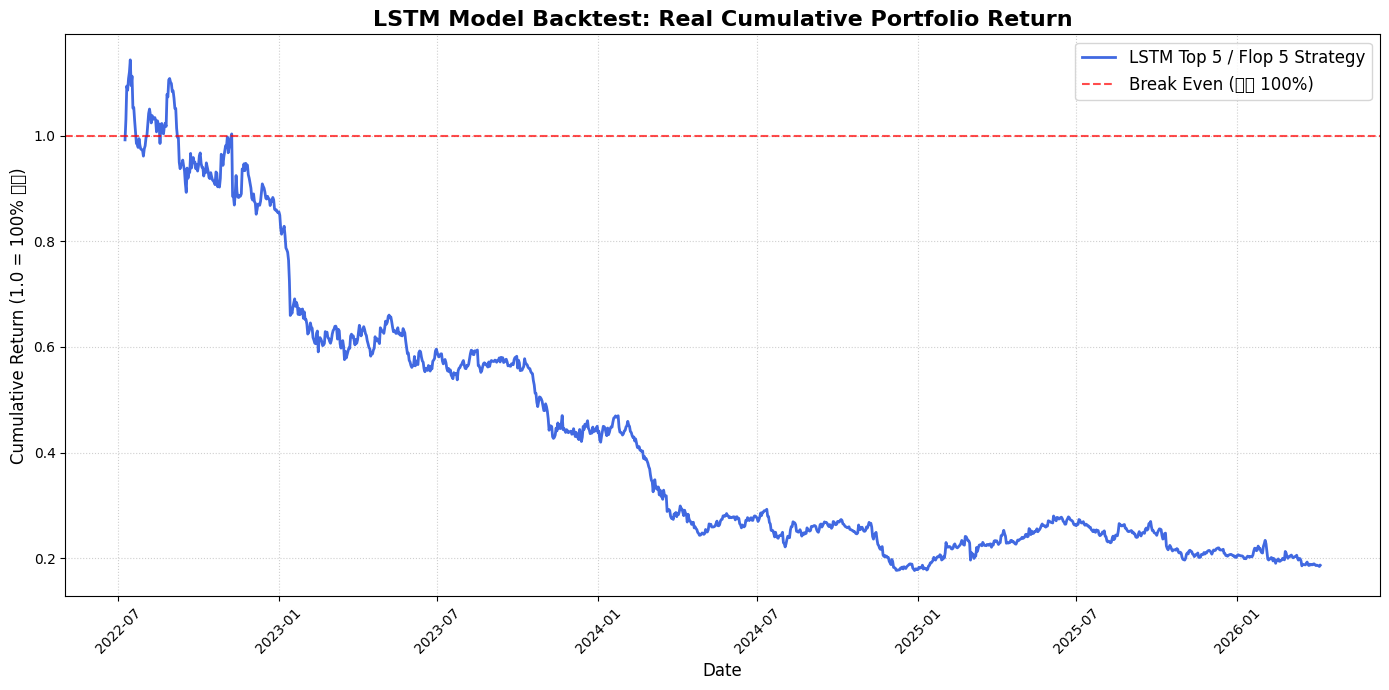


[최종 롤링 윈도우 백테스트 결과 요약]
전체 평균 Long 적중률   : 65.12%
전체 평균 Short 적중률  : 48.89%
전체 평균 종합 적중률   : 57.00%


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1번 스플릿부터 끝번 스플릿까지 고른 모든 주식 명단을 하나의 표로 합침
total_portfolio_df = pd.concat(all_portfolios).reset_index(drop=True)

# 원본 수익률 데이터(returns.csv) 불러오기
raw_returns_path = '../../tests/data_/returns.csv' 
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

# 병합을 위해 세로형(Long format)으로 변환
returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)

# 날짜 형식 일치시키기
total_portfolio_df['target_date'] = pd.to_datetime(total_portfolio_df['target_date'])
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 모델이 고른 종목표에 진짜 수익률(actual_return) 붙이기
total_portfolio_df = pd.merge(total_portfolio_df, returns_long, on=['target_date', 'ticker'], how='left')
total_portfolio_df['actual_return'] = total_portfolio_df['actual_return'].fillna(0)

# 포지션별(Long/Short) 수익률 계산 (각각 비중 20%)
def calc_position_return(row):
    if row['position'] == 'Long':
        return row['actual_return'] * (1/5)
    elif row['position'] == 'Short':
        return row['actual_return'] * (-1/5)
    return 0

total_portfolio_df['strategy_return'] = total_portfolio_df.apply(calc_position_return, axis=1)

# 매일매일의 총 수익률 합산 및 정렬
daily_returns = total_portfolio_df.groupby('target_date')['strategy_return'].sum().reset_index()
daily_returns = daily_returns.sort_values('target_date')

# 복리 누적 수익률(Cumulative Return) 계산 (원금 1.0)
daily_returns['cumulative_return'] = (1 + daily_returns['strategy_return']).cumprod()

# 시각화 
plt.figure(figsize=(14, 7))
plt.plot(daily_returns['target_date'], daily_returns['cumulative_return'], color='royalblue', linewidth=2, label='LSTM Top 5 / Flop 5 Strategy')

# 원금 기준선(1.0)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Break Even (원금 100%)')

plt.title('LSTM Model Backtest: Real Cumulative Portfolio Return', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 100% 원금)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 최종 요약 출력
print("\n" + "="*50)
print("[최종 롤링 윈도우 백테스트 결과 요약]")
if all_split_results:
    total_long = np.mean([res['long_hit'] for res in all_split_results])
    total_short = np.mean([res['short_hit'] for res in all_split_results])
    total_avg = np.mean([res['avg_hit'] for res in all_split_results])

    print(f"전체 평균 Long 적중률   : {total_long:.2f}%")
    print(f"전체 평균 Short 적중률  : {total_short:.2f}%")
    print(f"전체 평균 종합 적중률   : {total_avg:.2f}%")
print("="*50)

In [ ]:
from sklearn.linear_model import LogisticRegression

all_portfolios_log = []
print("LOG 모델 백테스트")

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0: continue 

    # 1. 데이터 준비 (2차원: samples, features)
    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values

    # 2. 모델 학습 및 예측
    log_model = LogisticRegression(random_state=42, max_iter=1000)
    log_model.fit(X_train, y_train)
    
    # 클래스 1(상회)이 될 확률 추출
    probs = log_model.predict_proba(X_test)[:, 1]

    # 3. 포트폴리오 구성
    test_df = test_df.copy()
    test_df['predict_prob'] = probs
    
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10: continue
        sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
        l, s = sorted_data.head(5).copy(), sorted_data.tail(5).copy()
        l['position'], s['position'] = 'Long', 'Short'
        portfolio_list.extend([l, s])
        
    if portfolio_list:
        all_portfolios_log.append(pd.concat(portfolio_list))
    print(f" -> Split {split_id} 완료")

LOG 모델 백테스트
 -> Split 1 완료
 -> Split 2 완료
 -> Split 3 완료
 -> Split 4 완료
 -> Split 5 완료
 -> Split 6 완료
 -> Split 7 완료
 -> Split 8 완료
 -> Split 9 완료


In [ ]:
from sklearn.ensemble import RandomForestClassifier

all_portfolios_raf = []
print("RAF 모델 백테스트")

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0: continue 

    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values

    # 모델 정의 (n_estimators 등 파라미터는 논문 설정에 따라 조정 가능)
    raf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42) #100 10 42
    raf_model.fit(X_train, y_train)
    
    probs = raf_model.predict_proba(X_test)[:, 1]

    test_df = test_df.copy()
    test_df['predict_prob'] = probs
    
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10: continue
        sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
        l, s = sorted_data.head(5).copy(), sorted_data.tail(5).copy()
        l['position'], s['position'] = 'Long', 'Short'
        portfolio_list.extend([l, s])
        
    if portfolio_list:
        all_portfolios_raf.append(pd.concat(portfolio_list))
    print(f" -> Split {split_id} 완료")

RAF 모델 백테스트
 -> Split 1 완료
 -> Split 2 완료
 -> Split 3 완료
 -> Split 4 완료
 -> Split 5 완료
 -> Split 6 완료
 -> Split 7 완료
 -> Split 8 완료
 -> Split 9 완료


In [13]:
# DNN 모델
from sklearn.neural_network import MLPClassifier

all_portfolios_dnn = []
print("DNN 모델 백테스트")

for split_id in unique_splits:
    split_df = df[df['split_id'] == split_id]
    train_df = split_df[split_df['dataset_type'] == 'Train']
    test_df = split_df[split_df['dataset_type'] == 'Test']
    
    if len(train_df) == 0 or len(test_df) == 0: continue 

    X_train = train_df[feature_cols].values
    y_train = train_df['target'].values
    X_test = test_df[feature_cols].values

    # 기본적인 MLP 분류기 (Hidden layers 크기는 자유롭게 조정)
    dnn_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42) #100 50 500
    dnn_model.fit(X_train, y_train)
    
    probs = dnn_model.predict_proba(X_test)[:, 1]

    test_df = test_df.copy()
    test_df['predict_prob'] = probs
    
    portfolio_list = []
    for date, daily_data in test_df.groupby('target_date'):
        if len(daily_data) < 10: continue
        sorted_data = daily_data.sort_values(by='predict_prob', ascending=False)
        l, s = sorted_data.head(5).copy(), sorted_data.tail(5).copy()
        l['position'], s['position'] = 'Long', 'Short'
        portfolio_list.extend([l, s])
        
    if portfolio_list:
        all_portfolios_dnn.append(pd.concat(portfolio_list))
    print(f" -> Split {split_id} 완료")

DNN 모델 백테스트
 -> Split 1 완료
 -> Split 2 완료
 -> Split 3 완료
 -> Split 4 완료
 -> Split 5 완료
 -> Split 6 완료
 -> Split 7 완료
 -> Split 8 완료
 -> Split 9 완료


4개 모델 누적 수익률 비교 시각화


C:\Users\skack\AppData\Local\Temp\ipykernel_18776\2258020927.py:92: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\2258020927.py:92: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\skack\anaconda3\envs\cs_stock\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44552 (\N{HANGUL SYLLABLE GEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


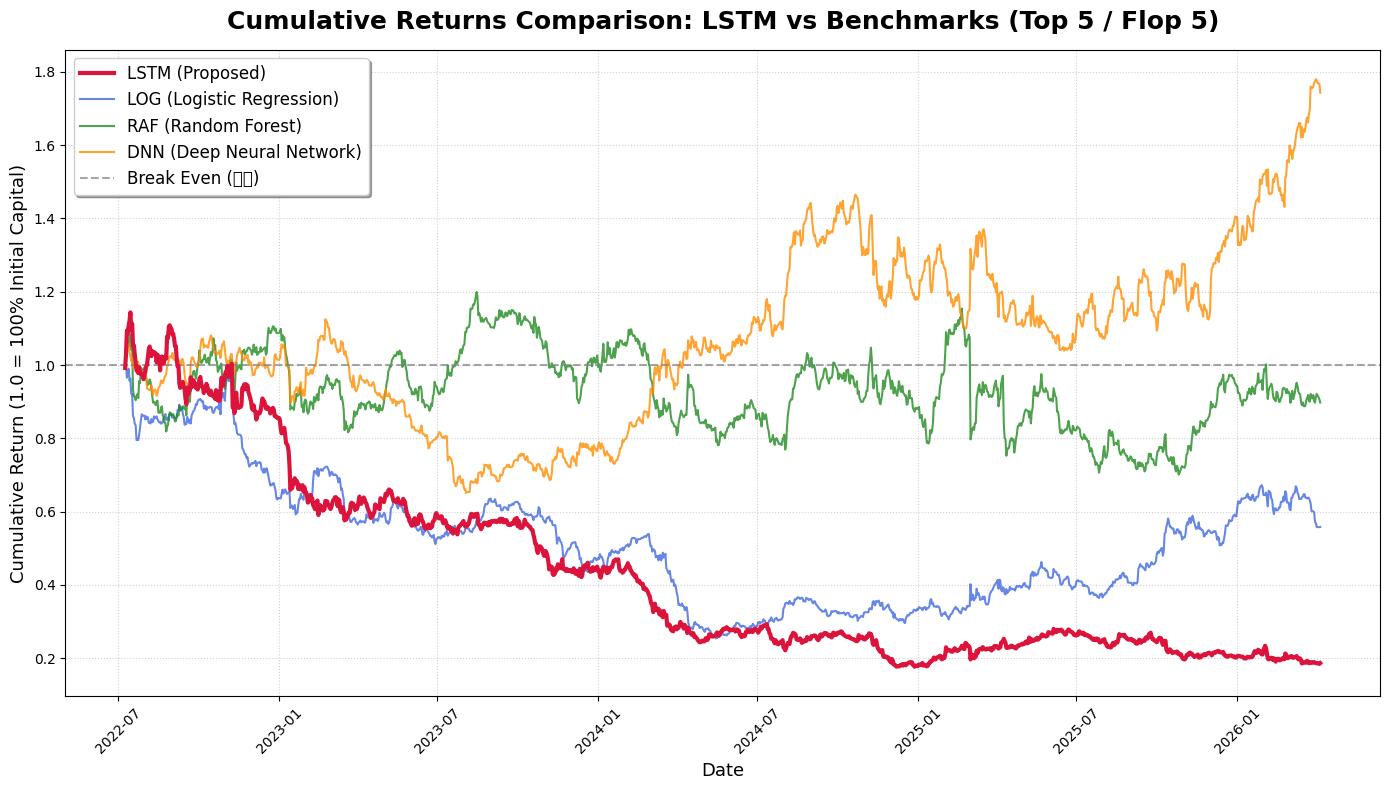

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("4개 모델 누적 수익률 비교 시각화")

# 원본 수익률 데이터(returns.csv) 한 번만 불러오기
raw_returns_path = '../../tests/data_/returns.csv'  # ⚠️ 파일 경로 확인 필수!
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 반복되는 수익률 계산 작업을 함수로 정의
def get_cumulative_returns(portfolio_list, returns_data):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    # 수익률 매핑 (VLOOKUP)
    df = pd.merge(df, returns_data, on=['target_date', 'ticker'], how='left')
    df['actual_return'] = df['actual_return'].fillna(0)
    
    # 롱/숏 포지션별 수익률 계산 (비중 1/5)
    def calc_ret(row):
        if row['position'] == 'Long': return row['actual_return'] * (1/5)
        elif row['position'] == 'Short': return row['actual_return'] * (-1/5)
        return 0
        
    df['strategy_return'] = df.apply(calc_ret, axis=1)
    
    # 일별 합산 및 누적 수익률(복리) 계산
    daily = df.groupby('target_date')['strategy_return'].sum().reset_index()
    daily = daily.sort_values('target_date')
    daily['cumulative_return'] = (1 + daily['strategy_return']).cumprod()
    
    return daily

# 4개 모델 각각 수익률 계산
lstm_returns = get_cumulative_returns(all_portfolios, returns_long)
log_returns = get_cumulative_returns(all_portfolios_log, returns_long)
raf_returns = get_cumulative_returns(all_portfolios_raf, returns_long)
dnn_returns = get_cumulative_returns(all_portfolios_dnn, returns_long)


# 1x1 통합 시각화
plt.figure(figsize=(14, 8))

# 주인공인 LSTM은 두껍고 강렬한 빨간색으로 강조
if lstm_returns is not None:
    plt.plot(lstm_returns['target_date'], lstm_returns['cumulative_return'], 
             label='LSTM (Proposed)', color='crimson', linewidth=3, zorder=5)

# 벤치마크 모델들은 각기 다른 색상으로 배치
if log_returns is not None:
    plt.plot(log_returns['target_date'], log_returns['cumulative_return'], 
             label='LOG (Logistic Regression)', color='royalblue', linewidth=1.5, alpha=0.8)

if raf_returns is not None:
    plt.plot(raf_returns['target_date'], raf_returns['cumulative_return'], 
             label='RAF (Random Forest)', color='forestgreen', linewidth=1.5, alpha=0.8)

if dnn_returns is not None:
    plt.plot(dnn_returns['target_date'], dnn_returns['cumulative_return'], 
             label='DNN (Deep Neural Network)', color='darkorange', linewidth=1.5, alpha=0.8)

# 원금 기준선 (1.0 = 100%)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='Break Even (원금)')

# 그래프 꾸미기
plt.title('Cumulative Returns Comparison: LSTM vs Benchmarks (Top 5 / Flop 5)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=13)
plt.ylabel('Cumulative Return (1.0 = 100% Initial Capital)', fontsize=13)

# 범례(Legend) 눈에 잘 띄게 배치
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

# x축 날짜 포맷팅
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

LSTM 모델: Long Only vs Short Only 수익 기여도 분석


C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\1142876398.py:83: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from 

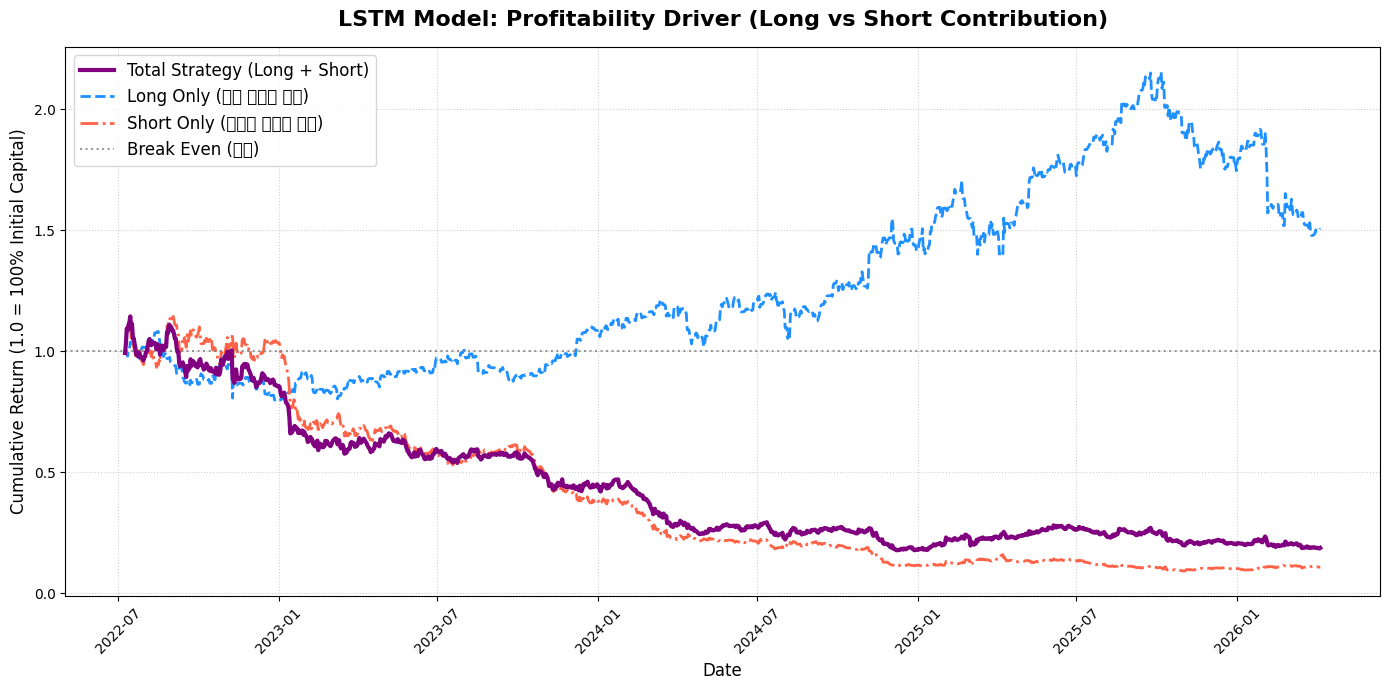

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("LSTM 모델: Long Only vs Short Only 수익 기여도 분석")

# 기존에 만들어둔 LSTM 포트폴리오 불러오기
df_all = pd.concat(all_portfolios).reset_index(drop=True)

# 원본 수익률 데이터 불러오기 및 맵핑 (이전과 동일)
raw_returns_path = '../../tests/data_/returns.csv'  # 경로 확인!
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])
df_all['target_date'] = pd.to_datetime(df_all['target_date'])

df_mapped = pd.merge(df_all, returns_long, on=['target_date', 'ticker'], how='left')
df_mapped['actual_return'] = df_mapped['actual_return'].fillna(0)

# 3가지 버전의 수익률 계산 로직
# 비중: 원래 포트폴리오가 Long 5개, Short 5개이므로 각각의 종목은 전체 자본의 10%(0.1)를 차지한다고 가정합니다.
# (만약 Long Only 펀드라면 5종목에 20%씩(0.2) 넣을 수도 있지만, 여기서는 '기여도'를 보기 위해 비중을 고정합니다)
weight_per_stock = 1 / 5 

def calc_long_only(row):
    if row['position'] == 'Long': return row['actual_return'] * weight_per_stock
    return 0

def calc_short_only(row):
    if row['position'] == 'Short': return row['actual_return'] * (-weight_per_stock)
    return 0

def calc_long_short(row):
    return calc_long_only(row) + calc_short_only(row)

df_mapped['ret_long_only'] = df_mapped.apply(calc_long_only, axis=1)
df_mapped['ret_short_only'] = df_mapped.apply(calc_short_only, axis=1)
df_mapped['ret_long_short'] = df_mapped.apply(calc_long_short, axis=1)

# 일별 합산 계산
daily_returns = df_mapped.groupby('target_date')[['ret_long_only', 'ret_short_only', 'ret_long_short']].sum().reset_index()
daily_returns = daily_returns.sort_values('target_date')

# 복리 누적 수익률 계산
daily_returns['cum_long'] = (1 + daily_returns['ret_long_only']).cumprod()
daily_returns['cum_short'] = (1 + daily_returns['ret_short_only']).cumprod()
daily_returns['cum_total'] = (1 + daily_returns['ret_long_short']).cumprod()

# 4. 시각화 그리기
plt.figure(figsize=(14, 7))

# 3개의 선 그리기
plt.plot(daily_returns['target_date'], daily_returns['cum_total'], 
         label='Total Strategy (Long + Short)', color='purple', linewidth=3, zorder=5)

plt.plot(daily_returns['target_date'], daily_returns['cum_long'], 
         label='Long Only (매수 포지션 수익)', color='dodgerblue', linewidth=2, linestyle='--')

plt.plot(daily_returns['target_date'], daily_returns['cum_short'], 
         label='Short Only (공매도 포지션 수익)', color='tomato', linewidth=2, linestyle='-.')

# 원금 기준선
plt.axhline(y=1.0, color='gray', linestyle=':', alpha=0.8, label='Break Even (원금)')

# 차트 꾸미기
plt.title('LSTM Model: Profitability Driver (Long vs Short Contribution)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 100% Initial Capital)', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

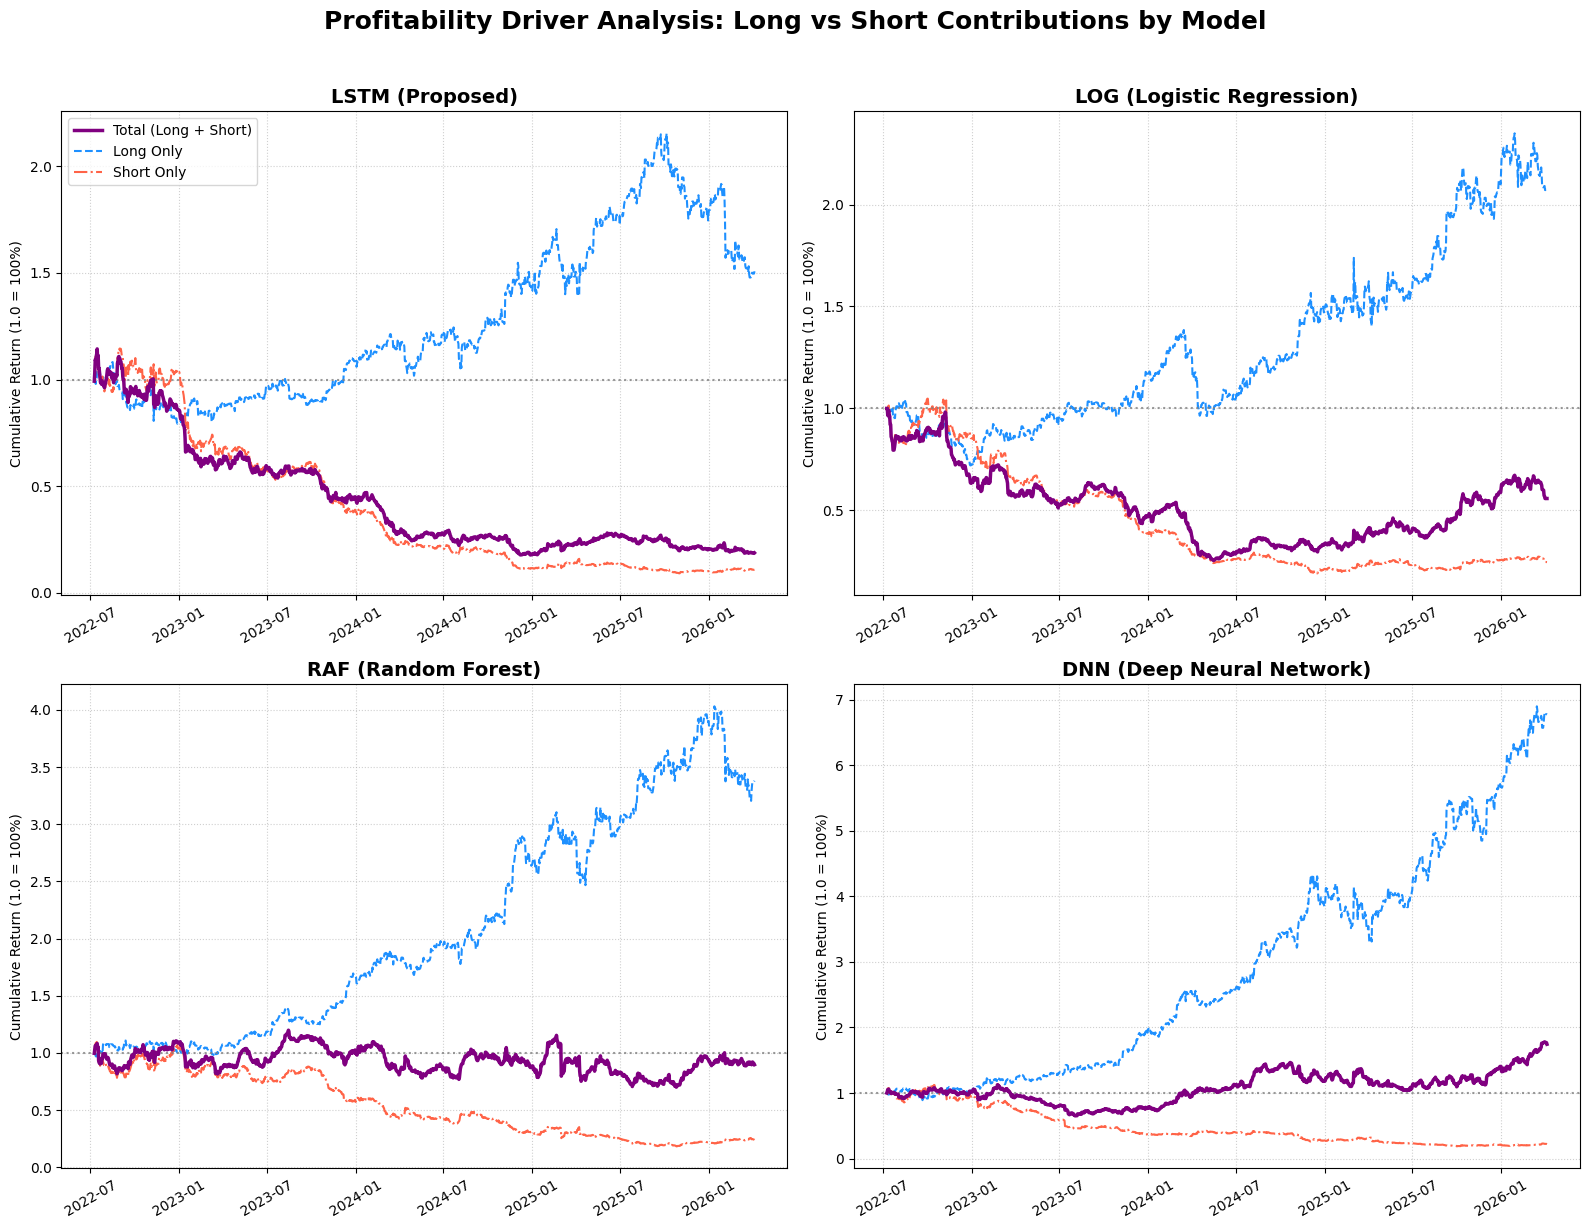

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 1. 원본 수익률 데이터 불러오기 및 전처리 (한 번만 수행)
raw_returns_path = '../../tests/data_/returns.csv'  # 경로 확인 필수
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 2. 포트폴리오별 Long/Short 누적 수익률 계산 함수
def get_ls_contribution(portfolio_list, returns_data):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    # 실제 수익률 매핑
    df_mapped = pd.merge(df, returns_data, on=['target_date', 'ticker'], how='left')
    df_mapped['actual_return'] = df_mapped['actual_return'].fillna(0)
    
    weight_per_stock = 1 / 5 
    
    # 포지션별 수익률 계산
    df_mapped['ret_long_only'] = np.where(df_mapped['position'] == 'Long', df_mapped['actual_return'] * weight_per_stock, 0)
    df_mapped['ret_short_only'] = np.where(df_mapped['position'] == 'Short', df_mapped['actual_return'] * (-weight_per_stock), 0)
    df_mapped['ret_total'] = df_mapped['ret_long_only'] + df_mapped['ret_short_only']
    
    # 일별 합산 계산
    daily = df_mapped.groupby('target_date')[['ret_long_only', 'ret_short_only', 'ret_total']].sum().reset_index()
    daily = daily.sort_values('target_date')
    
    # 누적 복리 수익률
    daily['cum_long'] = (1 + daily['ret_long_only']).cumprod()
    daily['cum_short'] = (1 + daily['ret_short_only']).cumprod()
    daily['cum_total'] = (1 + daily['ret_total']).cumprod()
    
    return daily

# 3. 4개 모델 데이터 계산
ls_lstm = get_ls_contribution(all_portfolios, returns_long)
ls_log = get_ls_contribution(all_portfolios_log, returns_long)
ls_raf = get_ls_contribution(all_portfolios_raf, returns_long)
ls_dnn = get_ls_contribution(all_portfolios_dnn, returns_long)

model_data = [
    ("LSTM (Proposed)", ls_lstm),
    ("LOG (Logistic Regression)", ls_log),
    ("RAF (Random Forest)", ls_raf),
    ("DNN (Deep Neural Network)", ls_dnn)
]

# ==============================================================================
# 4. 2x2 시각화 그리기
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (title, daily_returns) in enumerate(model_data):
    ax = axes[i]
    if daily_returns is None:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=15)
        ax.set_title(title, fontsize=14, fontweight='bold')
        continue

    # 선 그리기
    ax.plot(daily_returns['target_date'], daily_returns['cum_total'], 
             label='Total (Long + Short)', color='purple', linewidth=2.5, zorder=5)
    ax.plot(daily_returns['target_date'], daily_returns['cum_long'], 
             label='Long Only', color='dodgerblue', linewidth=1.5, linestyle='--')
    ax.plot(daily_returns['target_date'], daily_returns['cum_short'], 
             label='Short Only', color='tomato', linewidth=1.5, linestyle='-.')

    # 원금 기준선
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.8)

    # 서브플롯 꾸미기
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Cumulative Return (1.0 = 100%)', fontsize=10)
    
    # 첫 번째 그래프(LSTM)에만 범례 표시 (깔끔함을 위해)
    if i == 0:
        ax.legend(fontsize=10, loc='upper left')
        
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # x축 날짜 포맷
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Profitability Driver Analysis: Long vs Short Contributions by Model', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\skack\AppData\Local\Temp\ipykernel_18776\891937100.py:86: UserWarning: Glyph 51061 (\N{HANGUL SYLLABLE IG}) missing from font(s

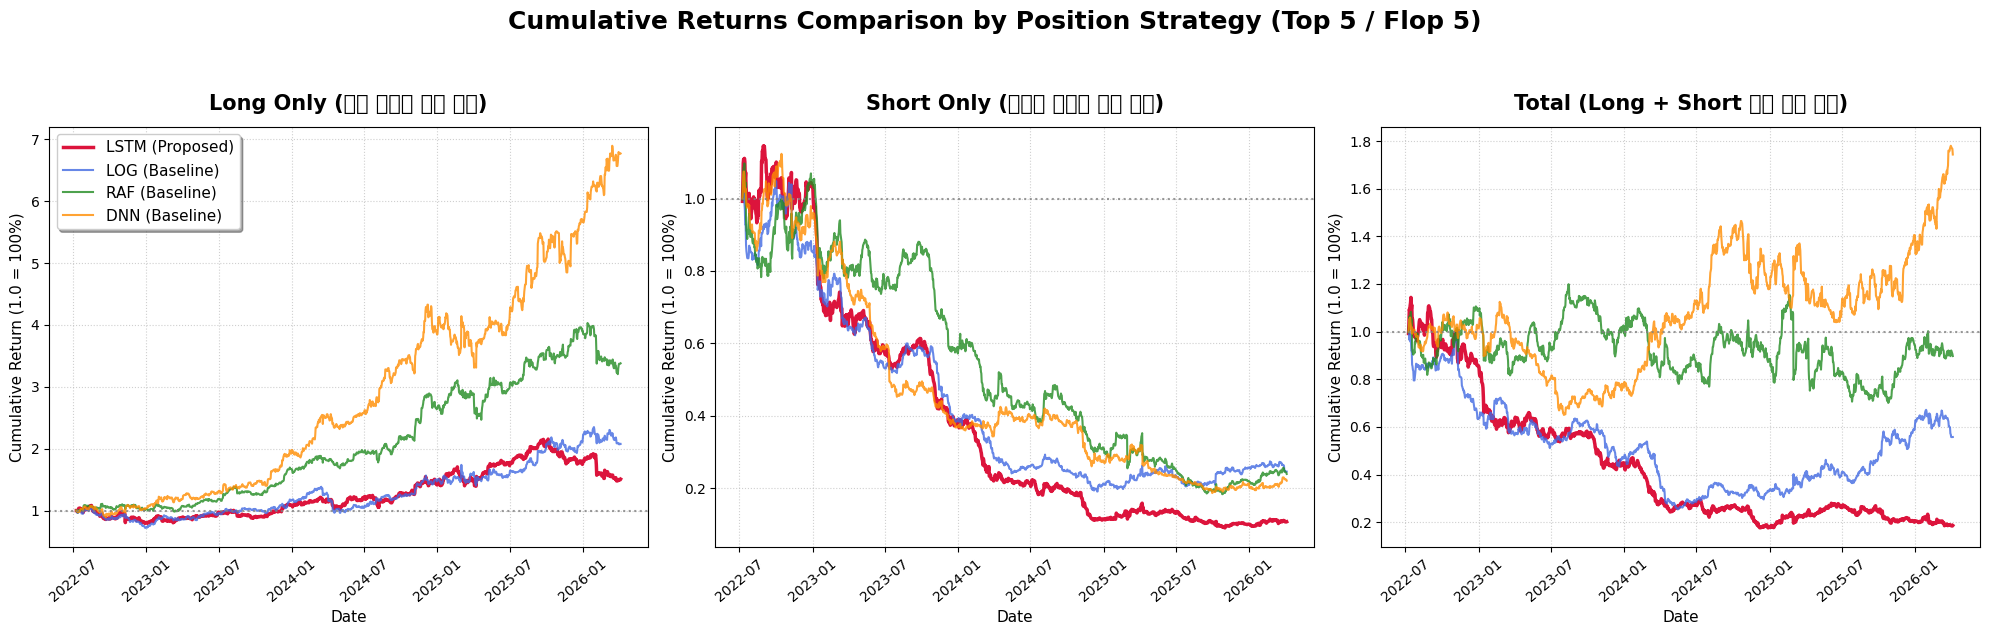

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 수익률 데이터 준비 및 병합을 위한 함수 (이전 셀에서 정의했지만 안전하게 다시 정의)
def get_ls_contribution(portfolio_list, returns_data):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    df_mapped = pd.merge(df, returns_data, on=['target_date', 'ticker'], how='left')
    df_mapped['actual_return'] = df_mapped['actual_return'].fillna(0)
    
    weight_per_stock = 1 / 5 
    df_mapped['ret_long_only'] = np.where(df_mapped['position'] == 'Long', df_mapped['actual_return'] * weight_per_stock, 0)
    df_mapped['ret_short_only'] = np.where(df_mapped['position'] == 'Short', df_mapped['actual_return'] * (-weight_per_stock), 0)
    df_mapped['ret_total'] = df_mapped['ret_long_only'] + df_mapped['ret_short_only']
    
    daily = df_mapped.groupby('target_date')[['ret_long_only', 'ret_short_only', 'ret_total']].sum().reset_index()
    daily = daily.sort_values('target_date')
    
    daily['cum_long'] = (1 + daily['ret_long_only']).cumprod()
    daily['cum_short'] = (1 + daily['ret_short_only']).cumprod()
    daily['cum_total'] = (1 + daily['ret_total']).cumprod()
    
    return daily

# 원본 데이터 로드
raw_returns_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)
returns_long = raw_returns.reset_index().melt(id_vars=raw_returns.index.name or 'index', var_name='ticker', value_name='actual_return')
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 4개 모델 계산
ls_lstm = get_ls_contribution(all_portfolios, returns_long)
ls_log  = get_ls_contribution(all_portfolios_log, returns_long)
ls_raf  = get_ls_contribution(all_portfolios_raf, returns_long)
ls_dnn  = get_ls_contribution(all_portfolios_dnn, returns_long)

# 2. 대망의 1x3 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    ("LSTM (Proposed)", ls_lstm, "crimson"),
    ("LOG (Baseline)", ls_log, "royalblue"),
    ("RAF (Baseline)", ls_raf, "forestgreen"),
    ("DNN (Baseline)", ls_dnn, "darkorange")
]

titles = ['Long Only (매수 포지션 수익 비교)', 
          'Short Only (공매도 포지션 수익 비교)', 
          'Total (Long + Short 통합 수익 비교)']

# 3개의 그래프를 순회하며 선 그리기
for name, data, color in models:
    if data is not None:
        # 두께 차별화 (LSTM은 두껍게, 나머지는 얇게)
        lw = 2.5 if "LSTM" in name else 1.5
        alpha = 1.0 if "LSTM" in name else 0.8
        
        axes[0].plot(data['target_date'], data['cum_long'], label=name, color=color, linewidth=lw, alpha=alpha)
        axes[1].plot(data['target_date'], data['cum_short'], label=name, color=color, linewidth=lw, alpha=alpha)
        axes[2].plot(data['target_date'], data['cum_total'], label=name, color=color, linewidth=lw, alpha=alpha)

# 각 그래프(서브플롯) 꾸미기
for i, ax in enumerate(axes):
    ax.set_title(titles[i], fontsize=15, fontweight='bold', pad=12)
    ax.axhline(y=1.0, color='gray', linestyle=':', alpha=0.8) # 원금 기준선
    ax.set_xlabel('Date', fontsize=11)
    ax.set_ylabel('Cumulative Return (1.0 = 100%)', fontsize=11)
    
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=40)
    
    # 범례는 복잡하니까 첫 번째 그래프에만 띄움
    if i == 0:
        ax.legend(fontsize=11, loc='upper left', frameon=True, shadow=True)

plt.suptitle('Cumulative Returns Comparison by Position Strategy (Top 5 / Flop 5)', fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

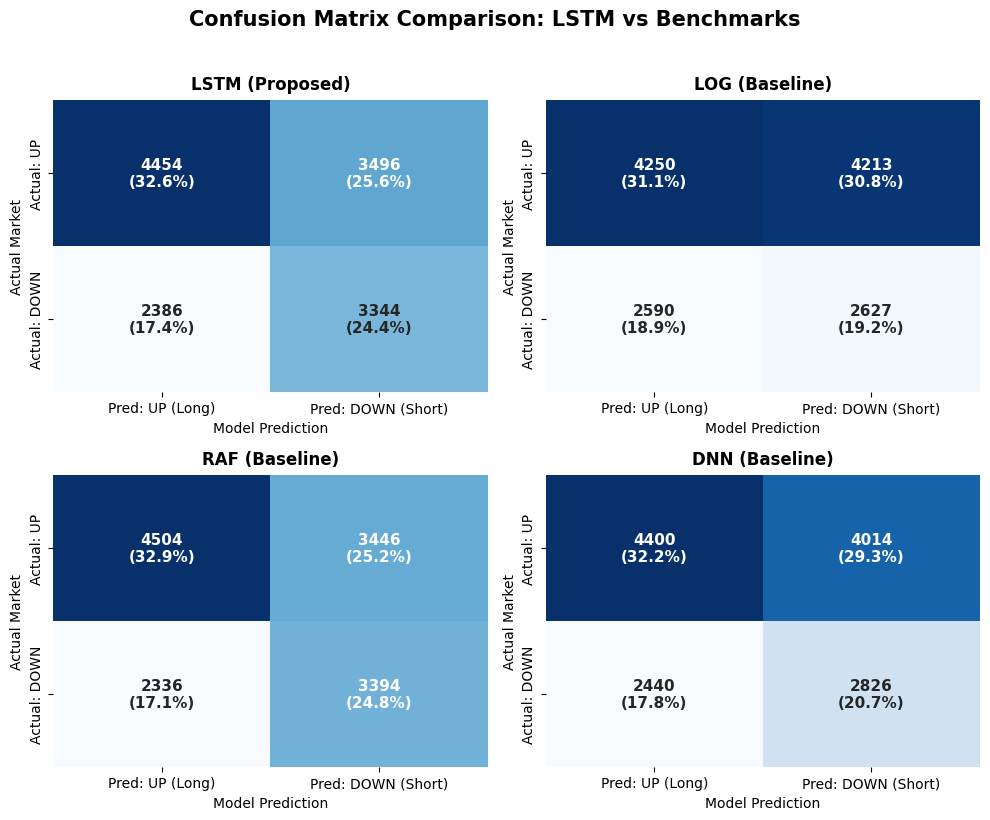


[ Performance Metrics Summary Table ]


,Accuracy,Precision,Recall,F1-Score
Model,,,,
LSTM (Proposed),57.00%,65.12%,56.03%,60.23%
LOG (Baseline),50.27%,62.13%,50.22%,55.54%
RAF (Baseline),57.73%,65.85%,56.65%,60.91%
DNN (Baseline),52.82%,64.33%,52.29%,57.69%


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# 1. 4개 모델의 포트폴리오 데이터를 딕셔너리로 묶기
model_baskets = {
    "LSTM (Proposed)": all_portfolios,
    "LOG (Baseline)": all_portfolios_log,
    "RAF (Baseline)": all_portfolios_raf,
    "DNN (Baseline)": all_portfolios_dnn
}

metrics_list = []

# 2. 그래프 크기 대폭 축소 (10 x 8)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# 3. 모델별 순회하며 행렬 그리기 및 지표 계산
for i, (name, portfolios) in enumerate(model_baskets.items()):
    ax = axes[i]

    if not portfolios:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', fontsize=12)
        ax.set_title(name, fontsize=12, fontweight='bold')
        continue

    # 데이터 병합 및 포지션을 이진 분류(1, 0)로 변환
    df = pd.concat(portfolios).reset_index(drop=True)
    df['predicted_class'] = np.where(df['position'] == 'Long', 1, 0)

    y_true = df['target'].values
    y_pred = df['predicted_class'].values

    # 혼동 행렬 계산
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    total = np.sum(cm)

    # 행렬 안의 숫자 포맷팅 (건수 및 %) - 글자 크기 축소
    annot_labels = np.array([
        [f"{cm[0, 0]}\n({cm[0, 0]/total*100:.1f}%)" if total > 0 else "0", 
         f"{cm[0, 1]}\n({cm[0, 1]/total*100:.1f}%)" if total > 0 else "0"],
        [f"{cm[1, 0]}\n({cm[1, 0]/total*100:.1f}%)" if total > 0 else "0", 
         f"{cm[1, 1]}\n({cm[1, 1]/total*100:.1f}%)" if total > 0 else "0"]
    ])

    # 히트맵 그리기
    sns.heatmap(cm, annot=annot_labels, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred: UP (Long)', 'Pred: DOWN (Short)'], 
                yticklabels=['Actual: UP', 'Actual: DOWN'],
                annot_kws={"size": 11, "weight": "bold"})

    ax.set_title(name, fontsize=12, fontweight='bold', pad=8)
    ax.set_xlabel('Model Prediction', fontsize=10)
    ax.set_ylabel('Actual Market', fontsize=10)

    # 4. 성능 지표 계산 및 리스트에 저장
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    metrics_list.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })

# 그래프 전체 제목 및 여백 조정
plt.suptitle('Confusion Matrix Comparison: LSTM vs Benchmarks', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# =====================================================================
# 5. 성능 지표 요약표 (DataFrame) 출력
# =====================================================================
if metrics_list:
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df.set_index("Model", inplace=True)

    # 모든 컬럼(Accuracy, Precision, Recall, F1-Score)에 대해 확실하게 % 포맷팅 적용
    metrics_df_formatted = metrics_df.copy()
    for col in metrics_df_formatted.columns:
        metrics_df_formatted[col] = metrics_df_formatted[col].apply(lambda x: f"{x*100:.2f}%")

    print("\n" + "="*70)
    print("[ Performance Metrics Summary Table ]")
    print("="*70)
    
    try:
        display(metrics_df_formatted)
    except NameError:
        print(metrics_df_formatted.to_string())
        
    print("="*70)

[System] Original LSTM vs Reverse LSTM 수익률 시각화 진행 중...


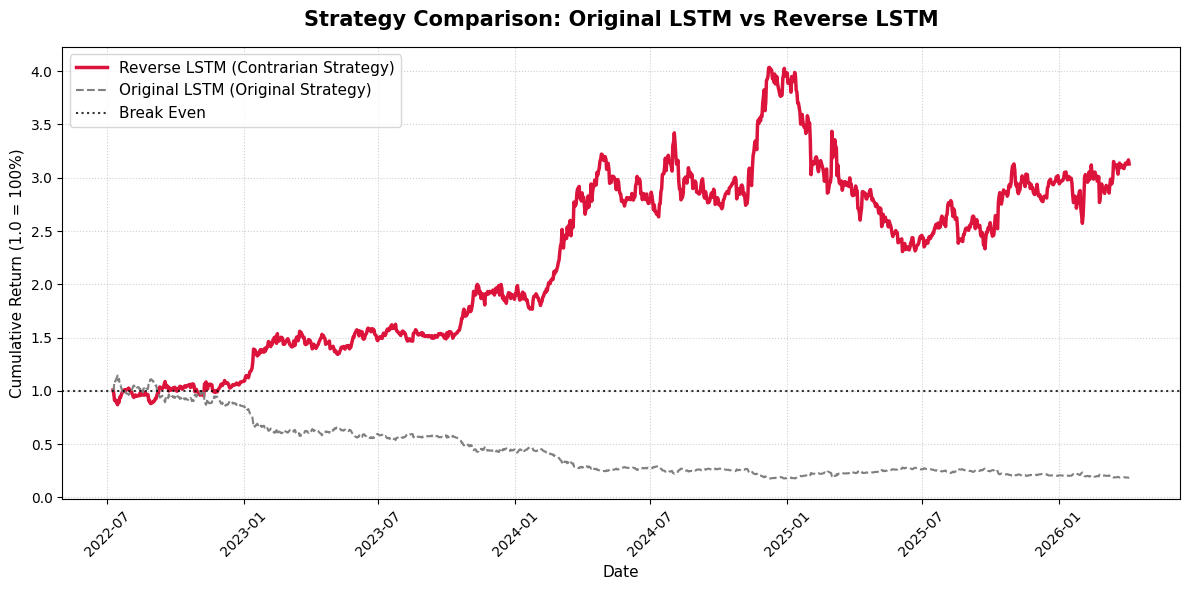

[ Cumulative Return Summary ]
Original LSTM Return :   -81.35%
Reverse LSTM Return  :   212.95%
-------------------------------------------------------


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[System] Original LSTM vs Reverse LSTM 수익률 시각화 진행 중...")

# 1. 기존 포트폴리오 불러오기
df_all = pd.concat(all_portfolios).reset_index(drop=True)
df_all['target_date'] = pd.to_datetime(df_all['target_date'])

# 2. 원본 수익률 데이터 불러오기
raw_returns_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 3. 데이터 병합
df_mapped = pd.merge(df_all, returns_long, on=['target_date', 'ticker'], how='left')
df_mapped['actual_return'] = df_mapped['actual_return'].fillna(0)

# 4. 수익률 계산 로직 (Original vs Reverse)
weight_per_stock = 1 / 5 

# 기존 전략 (Original)
df_mapped['ret_original'] = np.where(df_mapped['position'] == 'Long', df_mapped['actual_return'] * weight_per_stock,
                            np.where(df_mapped['position'] == 'Short', df_mapped['actual_return'] * (-weight_per_stock), 0))

# 청개구리 전략 (Reverse) - 포지션 스위칭!
# 모델이 Long을 외치면 Short을 치고, Short을 외치면 Long을 칩니다.
df_mapped['ret_reverse'] = np.where(df_mapped['position'] == 'Long', df_mapped['actual_return'] * (-weight_per_stock),
                           np.where(df_mapped['position'] == 'Short', df_mapped['actual_return'] * weight_per_stock, 0))

# 5. 일별 합산 및 누적 수익률 계산
daily = df_mapped.groupby('target_date')[['ret_original', 'ret_reverse']].sum().reset_index()
daily = daily.sort_values('target_date')

# 복리 계산
daily['cum_original'] = (1 + daily['ret_original']).cumprod()
daily['cum_reverse'] = (1 + daily['ret_reverse']).cumprod()

# 6. 시각화 그리기
plt.figure(figsize=(12, 6))

plt.plot(daily['target_date'], daily['cum_reverse'], 
         label='Reverse LSTM (Contrarian Strategy)', color='crimson', linewidth=2.5)

plt.plot(daily['target_date'], daily['cum_original'], 
         label='Original LSTM (Original Strategy)', color='gray', linewidth=1.5, linestyle='--')

# 원금 기준선
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.8, label='Break Even')

plt.title('Strategy Comparison: Original LSTM vs Reverse LSTM', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Cumulative Return (1.0 = 100%)', fontsize=11)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 7. 최종 누적 수익률 텍스트 출력
final_orig = daily['cum_original'].iloc[-1]
final_rev = daily['cum_reverse'].iloc[-1]

print("=" * 55)
print("[ Cumulative Return Summary ]")
print("=" * 55)
print(f"Original LSTM Return : {final_orig*100 - 100:8.2f}%")
print(f"Reverse LSTM Return  : {final_rev*100 - 100:8.2f}%")
print("-" * 55)

주식 시장에서 "최근 30일간 많이 오른 주식은 고평가되어 다음 날 떨어지고, 많이 떨어진 주식은 반등한다"는 특징이 강한 장세였다면, LSTM 모델이 "많이 오른 놈이 또 오른다(모멘텀)"라고 잘못 학습했을 가능성이 큼

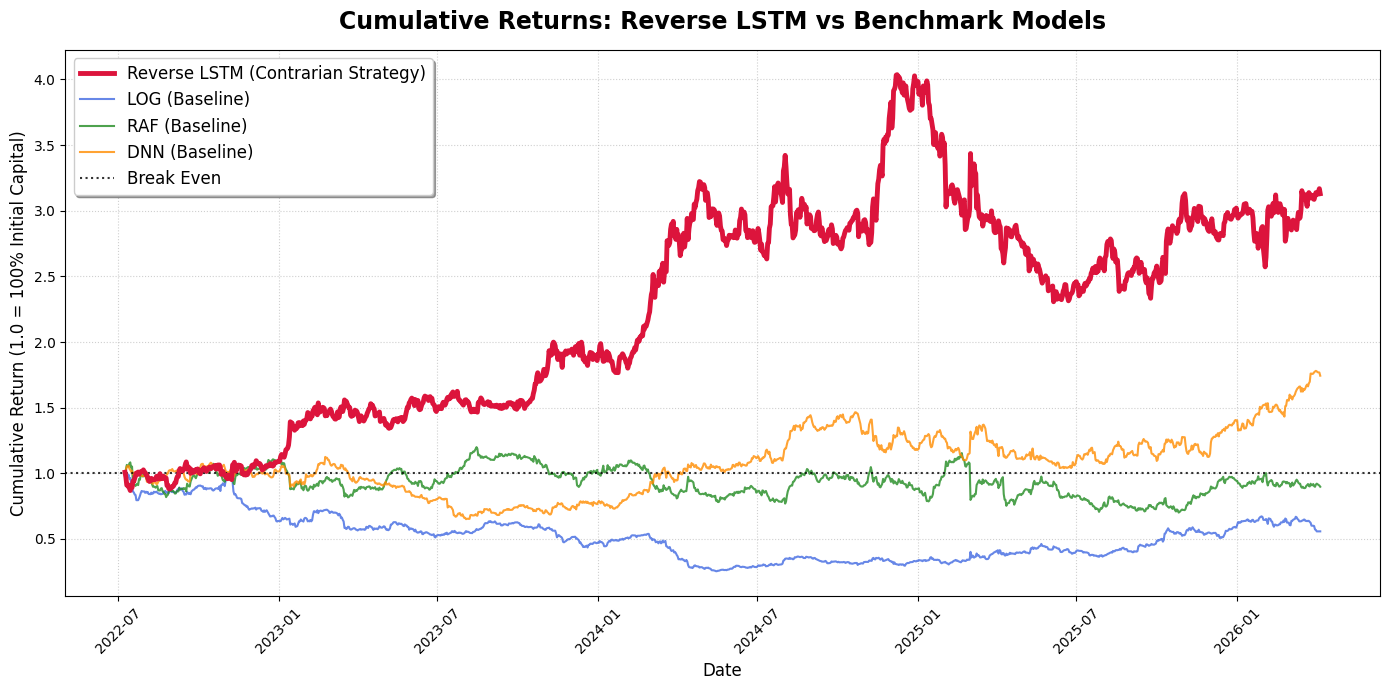

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


# 1. 원본 수익률 데이터 불러오기
raw_returns_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 2. 누적 수익률 계산 함수 (청개구리 모드 옵션 추가)
def get_cum_return(portfolio_list, is_reverse=False):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
    df['actual_return'] = df['actual_return'].fillna(0)
    
    weight = 1 / 5
    
    if is_reverse:
        # Reverse 모드: Long이라고 한 걸 Short으로(-), Short이라고 한 걸 Long으로(+)
        df['ret'] = np.where(df['position'] == 'Long', df['actual_return'] * (-weight),
                    np.where(df['position'] == 'Short', df['actual_return'] * weight, 0))
    else:
        # Normal 모드: 기존 그대로 계산
        df['ret'] = np.where(df['position'] == 'Long', df['actual_return'] * weight,
                    np.where(df['position'] == 'Short', df['actual_return'] * (-weight), 0))
        
    daily = df.groupby('target_date')['ret'].sum().reset_index()
    daily = daily.sort_values('target_date')
    daily['cum_ret'] = (1 + daily['ret']).cumprod()
    
    return daily

# 3. 각 모델별 누적 수익률 데이터 계산
# LSTM만 청개구리(Reverse) 모드로 계산하고, 나머지는 정상(Normal) 모드로 계산
rev_lstm_df = get_cum_return(all_portfolios, is_reverse=True)
log_df = get_cum_return(all_portfolios_log, is_reverse=False)
raf_df = get_cum_return(all_portfolios_raf, is_reverse=False)
dnn_df = get_cum_return(all_portfolios_dnn, is_reverse=False)

# ==============================================================================
# 4. 1x1 통합 시각화 그리기
# ==============================================================================
plt.figure(figsize=(14, 7))

# 주인공인 Reverse LSTM은 강렬한 빨간색으로 두껍게 강조
if rev_lstm_df is not None:
    plt.plot(rev_lstm_df['target_date'], rev_lstm_df['cum_ret'], 
             label='Reverse LSTM (Contrarian Strategy)', color='crimson', linewidth=3.5, zorder=5)

# 벤치마크 모델들은 각기 다른 색상으로 얇게 배치
if log_df is not None:
    plt.plot(log_df['target_date'], log_df['cum_ret'], 
             label='LOG (Baseline)', color='royalblue', linewidth=1.5, alpha=0.8)

if raf_df is not None:
    plt.plot(raf_df['target_date'], raf_df['cum_ret'], 
             label='RAF (Baseline)', color='forestgreen', linewidth=1.5, alpha=0.8)

if dnn_df is not None:
    plt.plot(dnn_df['target_date'], dnn_df['cum_ret'], 
             label='DNN (Baseline)', color='darkorange', linewidth=1.5, alpha=0.8)

# 원금 기준선
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.8, label='Break Even')

# 그래프 꾸미기
plt.title('Cumulative Returns: Reverse LSTM vs Benchmark Models', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 100% Initial Capital)', fontsize=12)
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

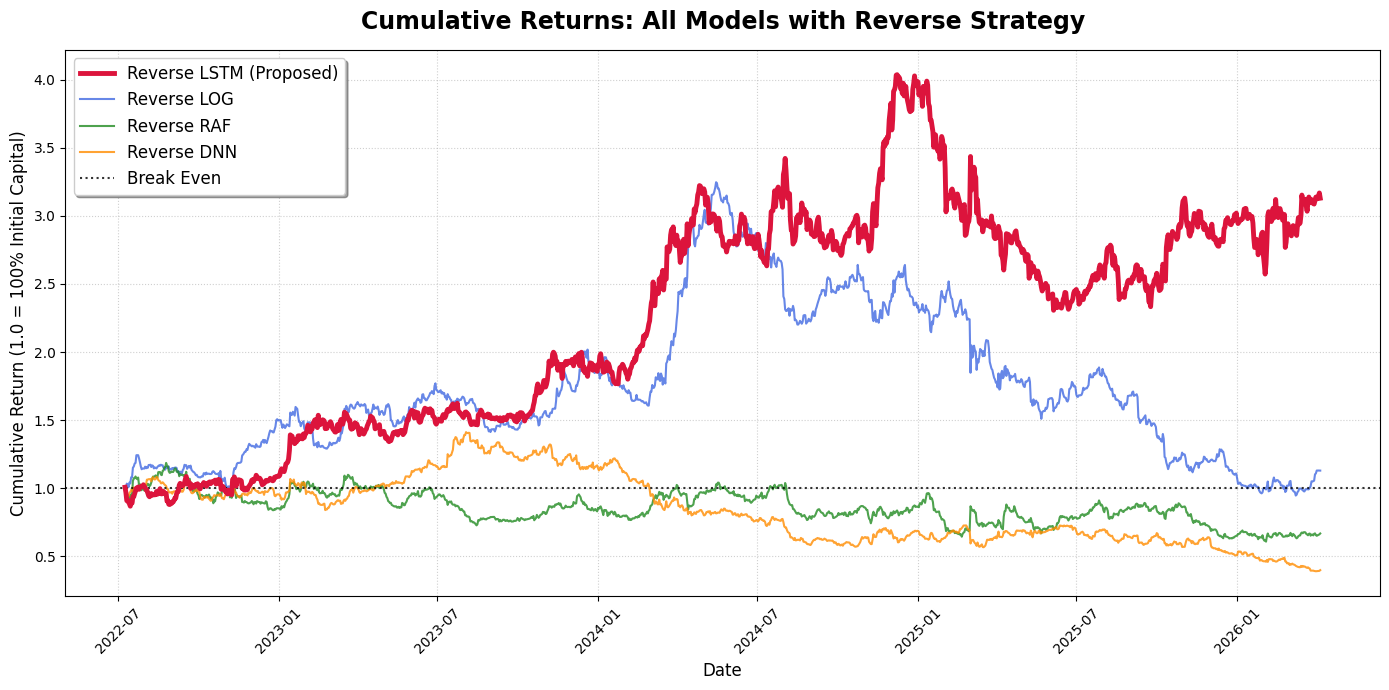


[ Final Cumulative Return Summary (Reverse Strategies) ]
Reverse LSTM :   212.95%
Reverse DNN  :   -60.06%
Reverse RAF  :   -33.15%
Reverse LOG  :    13.00%
------------------------------------------------------------


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 원본 수익률 데이터 불러오기
raw_returns_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 2. 누적 수익률 계산 함수 (Reverse 전용)
def get_reverse_cum_return(portfolio_list):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
    df['actual_return'] = df['actual_return'].fillna(0)
    
    weight = 1 / 5
    
    # 🔥 [핵심] Reverse 모드: Long 예측을 Short(-)으로, Short 예측을 Long(+)으로 강제 변환
    df['ret'] = np.where(df['position'] == 'Long', df['actual_return'] * (-weight),
                np.where(df['position'] == 'Short', df['actual_return'] * weight, 0))
        
    daily = df.groupby('target_date')['ret'].sum().reset_index()
    daily = daily.sort_values('target_date')
    daily['cum_ret'] = (1 + daily['ret']).cumprod()
    
    return daily

# 3. 4개 모델 모두 'Reverse 모드'로 데이터 계산
rev_lstm_df = get_reverse_cum_return(all_portfolios)
rev_log_df  = get_reverse_cum_return(all_portfolios_log)
rev_raf_df  = get_reverse_cum_return(all_portfolios_raf)
rev_dnn_df  = get_reverse_cum_return(all_portfolios_dnn)

# ==============================================================================
# 4. 1x1 통합 시각화 그리기
# ==============================================================================
plt.figure(figsize=(14, 7))

# 주인공인 Reverse LSTM은 강렬한 빨간색으로 두껍게 강조
if rev_lstm_df is not None:
    plt.plot(rev_lstm_df['target_date'], rev_lstm_df['cum_ret'], 
             label='Reverse LSTM (Proposed)', color='crimson', linewidth=3.5, zorder=5)

# 벤치마크 모델들은 각기 다른 색상으로 배치
if rev_log_df is not None:
    plt.plot(rev_log_df['target_date'], rev_log_df['cum_ret'], 
             label='Reverse LOG', color='royalblue', linewidth=1.5, alpha=0.8)

if rev_raf_df is not None:
    plt.plot(rev_raf_df['target_date'], rev_raf_df['cum_ret'], 
             label='Reverse RAF', color='forestgreen', linewidth=1.5, alpha=0.8)

if rev_dnn_df is not None:
    plt.plot(rev_dnn_df['target_date'], rev_dnn_df['cum_ret'], 
             label='Reverse DNN', color='darkorange', linewidth=1.5, alpha=0.8)

# 원금 기준선
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.8, label='Break Even')

# 그래프 꾸미기
plt.title('Cumulative Returns: All Models with Reverse Strategy', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 100% Initial Capital)', fontsize=12)
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. 최종 수익률 텍스트 출력
print("\n" + "=" * 60)
print("[ Final Cumulative Return Summary (Reverse Strategies) ]")
print("=" * 60)
if rev_lstm_df is not None: print(f"Reverse LSTM : {rev_lstm_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if rev_dnn_df is not None:  print(f"Reverse DNN  : {rev_dnn_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if rev_raf_df is not None:  print(f"Reverse RAF  : {rev_raf_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if rev_log_df is not None:  print(f"Reverse LOG  : {rev_log_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
print("-" * 60)

[System] 혼합 전략 (Reverse LSTM/LOG vs Normal RAF/DNN) 시각화 진행 중...


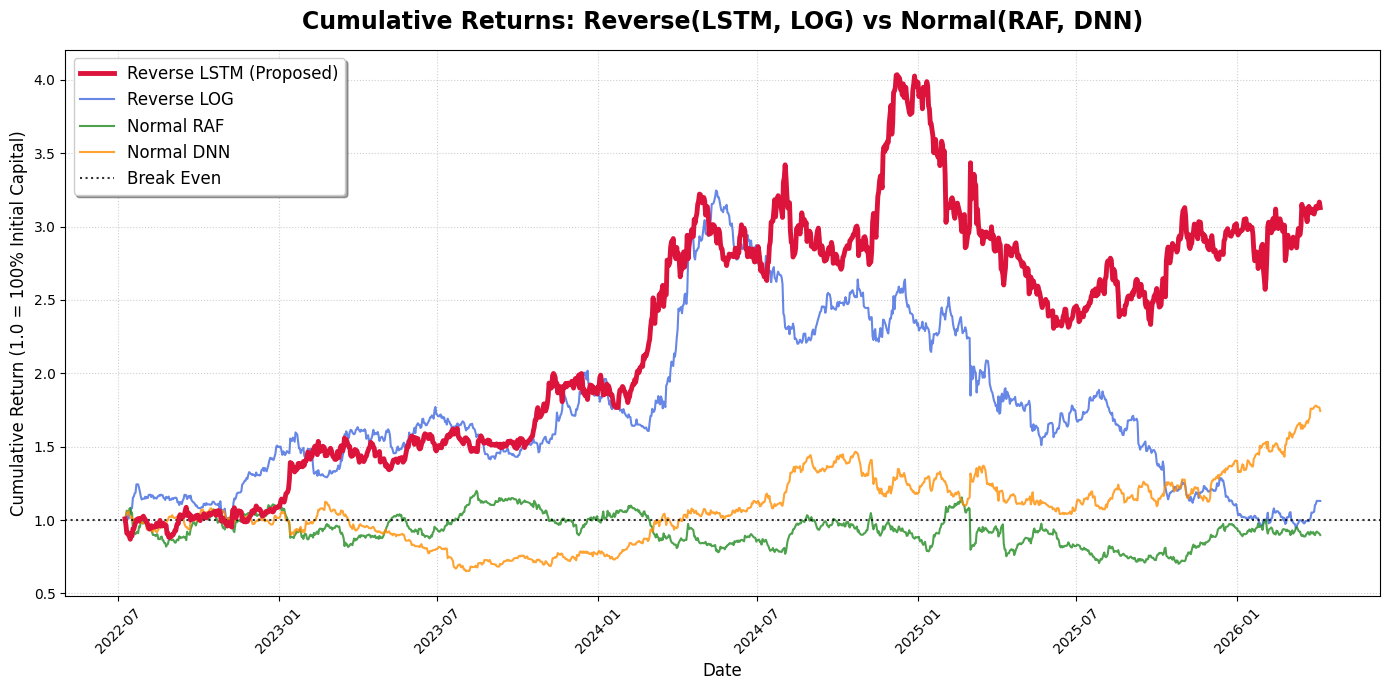


[ Final Cumulative Return Summary (Mixed Strategies) ]
Reverse LSTM :   212.95%
Reverse LOG  :    13.00%
Normal RAF   :   -10.24%
Normal DNN   :    74.33%
-----------------------------------------------------------------


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

print("[System] 혼합 전략 (Reverse LSTM/LOG vs Normal RAF/DNN) 시각화 진행 중...")

# 1. 원본 수익률 데이터 불러오기
raw_returns_path = '../../tests/data_/returns.csv'
raw_returns = pd.read_csv(raw_returns_path, index_col=0, parse_dates=True)

returns_long = raw_returns.reset_index().melt(
    id_vars=raw_returns.index.name or 'index', 
    var_name='ticker', 
    value_name='actual_return'
)
returns_long.rename(columns={returns_long.columns[0]: 'target_date'}, inplace=True)
returns_long['target_date'] = pd.to_datetime(returns_long['target_date'])

# 2. 누적 수익률 계산 함수 (is_reverse 파라미터로 뒤집기 여부 결정)
def get_cum_return(portfolio_list, is_reverse=False):
    if not portfolio_list:
        return None
        
    df = pd.concat(portfolio_list).reset_index(drop=True)
    df['target_date'] = pd.to_datetime(df['target_date'])
    
    df = pd.merge(df, returns_long, on=['target_date', 'ticker'], how='left')
    df['actual_return'] = df['actual_return'].fillna(0)
    
    weight = 1 / 5
    
    if is_reverse:
        # Reverse 모드: Long은 Short(-), Short은 Long(+)으로
        df['ret'] = np.where(df['position'] == 'Long', df['actual_return'] * (-weight),
                    np.where(df['position'] == 'Short', df['actual_return'] * weight, 0))
    else:
        # Normal 모드: 기존 그대로 계산
        df['ret'] = np.where(df['position'] == 'Long', df['actual_return'] * weight,
                    np.where(df['position'] == 'Short', df['actual_return'] * (-weight), 0))
        
    daily = df.groupby('target_date')['ret'].sum().reset_index()
    daily = daily.sort_values('target_date')
    daily['cum_ret'] = (1 + daily['ret']).cumprod()
    
    return daily

# 3. 모델별 데이터 계산 (요청하신 조건 적용)
# LSTM과 LOG는 뒤집고(Reverse), RAF와 DNN은 그대로(Normal)
mix_lstm_df = get_cum_return(all_portfolios, is_reverse=True)
mix_log_df  = get_cum_return(all_portfolios_log, is_reverse=True)
mix_raf_df  = get_cum_return(all_portfolios_raf, is_reverse=False)
mix_dnn_df  = get_cum_return(all_portfolios_dnn, is_reverse=False)

# ==============================================================================
# 4. 1x1 통합 시각화 그리기
# ==============================================================================
plt.figure(figsize=(14, 7))

# Reverse LSTM (주인공)
if mix_lstm_df is not None:
    plt.plot(mix_lstm_df['target_date'], mix_lstm_df['cum_ret'], 
             label='Reverse LSTM (Proposed)', color='crimson', linewidth=3.5, zorder=5)

# Reverse LOG
if mix_log_df is not None:
    plt.plot(mix_log_df['target_date'], mix_log_df['cum_ret'], 
             label='Reverse LOG', color='royalblue', linewidth=1.5, alpha=0.8)

# Normal RAF
if mix_raf_df is not None:
    plt.plot(mix_raf_df['target_date'], mix_raf_df['cum_ret'], 
             label='Normal RAF', color='forestgreen', linewidth=1.5, alpha=0.8)

# Normal DNN
if mix_dnn_df is not None:
    plt.plot(mix_dnn_df['target_date'], mix_dnn_df['cum_ret'], 
             label='Normal DNN', color='darkorange', linewidth=1.5, alpha=0.8)

# 원금 기준선
plt.axhline(y=1.0, color='black', linestyle=':', alpha=0.8, label='Break Even')

# 그래프 꾸미기
plt.title('Cumulative Returns: Reverse(LSTM, LOG) vs Normal(RAF, DNN)', fontsize=17, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (1.0 = 100% Initial Capital)', fontsize=12)
plt.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 5. 최종 수익률 텍스트 출력
print("\n" + "=" * 65)
print("[ Final Cumulative Return Summary (Mixed Strategies) ]")
print("=" * 65)
if mix_lstm_df is not None: print(f"Reverse LSTM : {mix_lstm_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if mix_log_df is not None:  print(f"Reverse LOG  : {mix_log_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if mix_raf_df is not None:  print(f"Normal RAF   : {mix_raf_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
if mix_dnn_df is not None:  print(f"Normal DNN   : {mix_dnn_df['cum_ret'].iloc[-1]*100 - 100:8.2f}%")
print("-" * 65)